In [1]:
import os

folder_path = r"C:\Users\yuvas\Downloads\sms+spam+collection (1)"

print(os.listdir(folder_path))


['SMSSpamCollection']


In [2]:
import pandas as pd

file_path = r"C:\Users\yuvas\Downloads\sms+spam+collection (1)\SMSSpamCollection"

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5572, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [5]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(403)

In [7]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

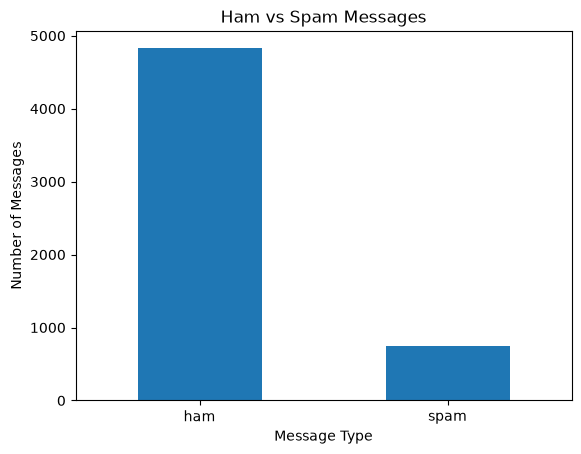

In [8]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Ham vs Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.show()

In [9]:
df = df.drop_duplicates()

df.shape

(5169, 2)

In [10]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
X = df["message"]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5169,)
y shape: (5169,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4135,)
Testing data: (1034,)


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 7680)
Testing TF-IDF shape: (1034, 7680)


In [14]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [15]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9526112185686654
Accuracy (%): 95.26112185686654


In [17]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       1.00      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.96      0.95      0.95      1034



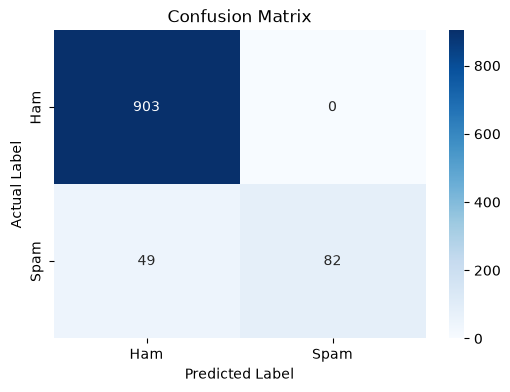

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [19]:
custom_messages = [
    "Congratulations! You have won a free prize. Click now to claim.",
    "Hi, are we meeting for lunch today?",
    "URGENT! You have won a cash reward. Call now!",
    "Can you send me the notes from today's class?"
]

custom_tfidf = vectorizer.transform(custom_messages)

custom_predictions = model.predict(custom_tfidf)

for message, prediction in zip(custom_messages, custom_predictions):
    result = "Spam" if prediction == 1 else "Ham"
    print("Message:", message)
    print("Prediction:", result)
    print("-" * 60)

Message: Congratulations! You have won a free prize. Click now to claim.
Prediction: Spam
------------------------------------------------------------
Message: Hi, are we meeting for lunch today?
Prediction: Ham
------------------------------------------------------------
Message: URGENT! You have won a cash reward. Call now!
Prediction: Spam
------------------------------------------------------------
Message: Can you send me the notes from today's class?
Prediction: Ham
------------------------------------------------------------


## Model Performance Summary

The Email Spam Detection model was built using TF-IDF text vectorization and the Multinomial Naive Bayes algorithm.

The dataset was divided into 80% training data and 20% testing data. The model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

The model was also tested with new custom SMS messages to verify its ability to classify unseen messages as Ham or Spam.

## Conclusion

The Email Spam Detection project successfully developed a machine learning model to classify SMS messages as Ham or Spam.

TF-IDF was used to convert text messages into numerical features, and Multinomial Naive Bayes was used for classification. The model achieved good performance on the test dataset based on accuracy, precision, recall, and F1-score.

The confusion matrix helped analyze correct and incorrect predictions. The model was also tested on new messages and successfully demonstrated its ability to classify unseen SMS messages.

This project demonstrates the application of Natural Language Processing (NLP) and Machine Learning for automatic spam message detection.s